In [353]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "BkQo1WObUd_cdaOmW3tQfymyGavrrPCmEqPsZwRS3-yTHZzECj5j_6X8MLQRdhbYtTnxKR6rDSi6Wne7g03VBA=="

# Initialize the client
import datetime
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [354]:
time_start = "-1m"
time_stop = "now()"
window = "1s"

query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "robotarm.pt.state")
  |> filter(fn: (r) => r["_field"] =~ /q_actual_[0-6]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_model_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "robotarm.dt.state")
  |> filter(fn: (r) => r["_field"] =~ /q_actual_[0-6]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_model_data = query_api.query_data_frame(query_model_data)

In [355]:
print(df_sensor_data.head())

    result  table                            _time  \
0  _result      0 2026-05-22 12:28:51.649438+00:00   
1  _result      0 2026-05-22 12:28:51.699370+00:00   
2  _result      0 2026-05-22 12:28:51.748819+00:00   
3  _result      0 2026-05-22 12:28:51.798141+00:00   
4  _result      0 2026-05-22 12:28:51.848318+00:00   

                            _start                            _stop  \
0 2026-05-22 12:28:51.598947+00:00 2026-05-22 12:29:51.598947+00:00   
1 2026-05-22 12:28:51.598947+00:00 2026-05-22 12:29:51.598947+00:00   
2 2026-05-22 12:28:51.598947+00:00 2026-05-22 12:29:51.598947+00:00   
3 2026-05-22 12:28:51.598947+00:00 2026-05-22 12:29:51.598947+00:00   
4 2026-05-22 12:28:51.598947+00:00 2026-05-22 12:29:51.598947+00:00   

        _measurement           msg_type    q_actual_0    q_actual_1  \
0  robotarm.pt.state  PhysicalTwinState -1.133141e-07 -7.297165e-03   
1  robotarm.pt.state  PhysicalTwinState  2.149129e-07 -1.824405e-03   
2  robotarm.pt.state  PhysicalTwinS

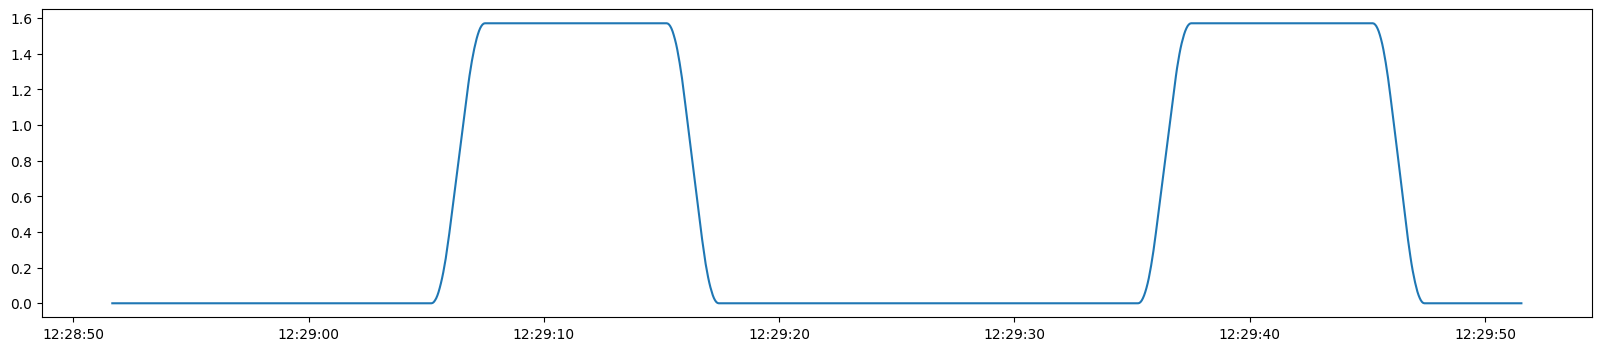

In [356]:
sensor_data_np = df_sensor_data["q_actual_0"].to_numpy()
t = df_sensor_data["_time"].to_numpy()

plt.figure(figsize=(20, 4))

plt.plot(t, sensor_data_np)

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


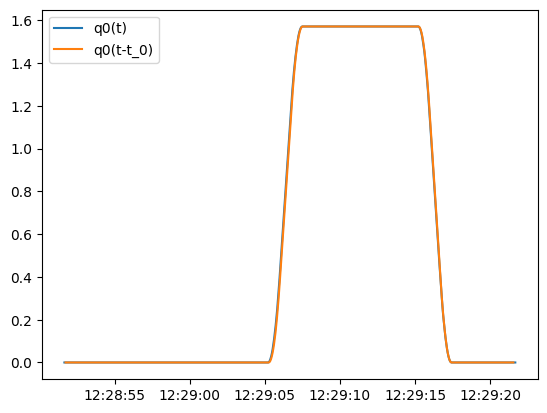

In [357]:
print(type(t[0]))

dt = pd.Timedelta(seconds=30)

t1 = t
t2 = t - dt

lim1, lim2 = 600, 600

plt.plot(t1[:lim1], sensor_data_np[:lim1], label="q0(t)")
plt.plot(t2[lim2:], sensor_data_np[lim2:], label="q0(t-t_0)")
plt.legend()